## **Phase 2A: Route Extension & Ranking**

**Imports**

This cell loads all required libraries for the second phase of the project: extending and ranking bus routes.  
It brings together tools for:

- **Data manipulation**: `pandas`, `numpy`  
- **Visualization**: `matplotlib`, `seaborn`  
- **Spatial analysis and geodata**: `geopandas`, `shapely`  
- **Spatial search**: `cKDTree`  
- **Transit data processing (GTFS)**: `gtfs_kit`  
- **Street network analysis**: `osmnx`  

These imports prepare the environment for analyzing route geometry, evaluating route performance, and exploring potential extensions using both GTFS data and OSM street networks.

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, LineString
from scipy.spatial import cKDTree
import warnings
import gtfs_kit as gk
import osmnx as ox
warnings.filterwarnings('ignore')

print("Phase 2: Route Extension & Ranking")
print("="*70)

Phase 2: Route Extension & Ranking


### ii. Loading GNN Predictions and GTFS Data

In this step, we bring together all the core datasets needed to begin route extension and ranking:

- **High-quality stop candidates** predicted by the Phase 1 GNN  
- The **full stop-feature dataset**, providing spatial and service attributes  
- A complete **GTFS feed** (routes, trips, stop times, shapes, stops), giving us the structure of the existing transit network  

Loading these resources up front ensures the notebook has everything required to:

- Analyze current route geometry  
- Compare existing routes with high-potential GNN candidate stops  
- Identify realistic extension points  
- Score and rank routes based on improvement opportunities  

This establishes the foundation for the route-level analysis that follows.

In [2]:
# Load GNN predictions and GTFS data

# Load GNN candidate predictions and stop feature data
predictions_df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_output/all_candidates_equity.csv')
df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_training_data.csv')

print("Loading GTFS data...")
feed_path = '/home/dataopske/Desktop/jav/data/raw/digitalmatatu/GTFS_FEED_2019.zip'
feed = gk.read_feed(feed_path, dist_units='km')

gtfs_routes = feed.routes
gtfs_trips = feed.trips
gtfs_stop_times = feed.stop_times
gtfs_stops = feed.stops.copy()
gtfs_shapes = feed.shapes

print(f"✓ GTFS loaded: {len(gtfs_routes)} routes, {len(gtfs_stops)} stops")
print(f"Route IDs: {gtfs_routes['route_id'].unique()[:5]}...")

print(f"\nLoaded {len(predictions_df)} candidate stops")
print("\nCandidates by ward category:")
print(predictions_df['ward_category'].value_counts())

print(f"\nGTFS stops: {len(gtfs_stops)}")

Loading GTFS data...
✓ GTFS loaded: 136 routes, 4284 stops
Route IDs: <StringArray>
['10000107D11', '10000114011', '10000116011', '10100011A11', '10200010811']
Length: 5, dtype: string...

Loaded 62 candidate stops

Candidates by ward category:
ward_category
adequately_served       48
underserved             11
severely_underserved     3
Name: count, dtype: int64

GTFS stops: 4284


### iii. Selecting Target Wards

In this step, we identify the wards that will be the focus for route extension.  
We select all wards classified as **underserved** or **severely underserved** and filter the GNN candidate stops to keep only those located within these priority areas. To select specific wards uncomment Option A and manually select the Wards.

The output lists:
- The number of target wards  
- The number of candidate stops within them  
- A per-ward breakdown of candidate counts  

This sets the geographic scope for the next steps in evaluating and extending routes.

In [3]:
# Cell 3: Select target wards
# Option A: Manually select wards
# target_wards = [
#     'Mathare North Ward',
#     'Korogocho Ward', 
#     'Sarang\'ombe Ward',
#     'Embakasi Ward',
#     'Airbase Ward'
# ]

# Option B: All underserved/severely underserved
target_wards = predictions_df[
    predictions_df['ward_category'].isin(['underserved', 'severely_underserved'])
]['ward'].unique().tolist()

# Filter candidates
selected_candidates = predictions_df[
    predictions_df['ward'].isin(target_wards)
].copy()

print(f"Selected {len(target_wards)} wards")
print(f"Found {len(selected_candidates)} candidates in these wards\n")

for ward in target_wards:
    ward_cands = selected_candidates[selected_candidates['ward'] == ward]
    print(f"  {ward}: {len(ward_cands)} candidates")

Selected 9 wards
Found 14 candidates in these wards

  Nairobi West Ward: 2 candidates
  Gatina Ward: 1 candidates
  Upper Savanna Ward: 1 candidates
  Pipeline Ward: 3 candidates
  Ngando Ward: 1 candidates
  Imara Daima Ward: 2 candidates
  Roysambu Ward: 1 candidates
  Airbase Ward: 1 candidates
  Embakasi Ward: 2 candidates


### iv. Snapping Candidate Stops to the Road Network

In this step, we align candidate stop locations to the nearest road segment from the OpenStreetMap (OSM) street network.  
This is important because raw candidate coordinates may fall slightly off-road due to GPS noise, digitization issues, or centroid-based placement.

The process includes:

- Loading or downloading the Nairobi **drive network** from OSM  
- Finding the nearest road network node for each candidate stop  
- Measuring how far each stop needed to move (snap distance)  
- Keeping the original coordinates if the nearest road is more than 50 m away  
- Replacing each stop’s coordinates with its snapped location  
- Visualizing the before/after positions for a sample of points

This ensures that all candidate stops sit directly on the road graph, making downstream route extension, pathfinding, and snapping to shapes far more reliable. The saved visualization helps confirm that snapping behaved as expected.


In [4]:
# Cell 5.5: Snap candidate stops to nearest roads
print("="*70)
print("SNAPPING CANDIDATES TO ROADS")
print("="*70)

# load osm road network
print("Downloading road network...")
try:
    G = ox.load_graphml('/home/dataopske/Desktop/jav/data/processed/nairobi_drive.graphml')
except:
    G = ox.graph_from_place("Nairobi, Kenya", network_type='drive')
    ox.save_graphml(G, 'nairobi_roads.graphml')
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
print("✓ Road network loaded.")

def snap_to_nearest_road(lat, lon, G, max_distance=50):
    """Snap a point to nearest road in OSM graph"""
    try:
        # Find nearest node in road network
        nearest_node = ox.distance.nearest_nodes(G, lon, lat)
        node_data = G.nodes[nearest_node]
        
        snapped_lat = node_data['y']
        snapped_lon = node_data['x']
        
        # Calculate snap distance
        from math import radians, sin, cos, sqrt, atan2
        R = 6371000  # Earth radius in meters
        
        lat1, lon1 = radians(lat), radians(lon)
        lat2, lon2 = radians(snapped_lat), radians(snapped_lon)
        
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance = R * c
        
        if distance <= max_distance:
            return snapped_lat, snapped_lon, distance
        else:
            return lat, lon, distance  # Keep original if too far
            
    except Exception as e:
        return lat, lon, None

# Snap all candidates
print(f"Snapping {len(selected_candidates)} candidates to roads...")
snapped_coords = []
snap_distances = []

for idx, row in selected_candidates.iterrows():
    snapped_lat, snapped_lon, distance = snap_to_nearest_road(
        row['lat'], row['lon'], G, max_distance=50
    )
    snapped_coords.append((snapped_lat, snapped_lon))
    snap_distances.append(distance)

# Update coordinates
selected_candidates['lat_original'] = selected_candidates['lat']
selected_candidates['lon_original'] = selected_candidates['lon']
selected_candidates['lat'] = [coord[0] for coord in snapped_coords]
selected_candidates['lon'] = [coord[1] for coord in snapped_coords]
selected_candidates['snap_distance'] = snap_distances

print(f"\n Snapped {len(selected_candidates)} stops to roads")
valid_distances = [d for d in snap_distances if d is not None]
print(f"   Mean snap distance: {np.mean(valid_distances):.1f}m")
print(f"   Median snap distance: {np.median(valid_distances):.1f}m")
print(f"   Max snap distance: {np.max(valid_distances):.1f}m")

# Check for poorly snapped stops
poorly_snapped = selected_candidates[
    (selected_candidates['snap_distance'].notna()) & 
    (selected_candidates['snap_distance'] > 50)
]
if len(poorly_snapped) > 0:
    print(f"\n {len(poorly_snapped)} stops snapped >50m away (kept original coords)")

SNAPPING CANDIDATES TO ROADS
✓ Road network loaded.
Snapping 14 candidates to roads...

 Snapped 14 stops to roads
   Mean snap distance: 107.0m
   Median snap distance: 102.2m
   Max snap distance: 239.7m

 11 stops snapped >50m away (kept original coords)



Saved visualization to road_snapping_visualization.png


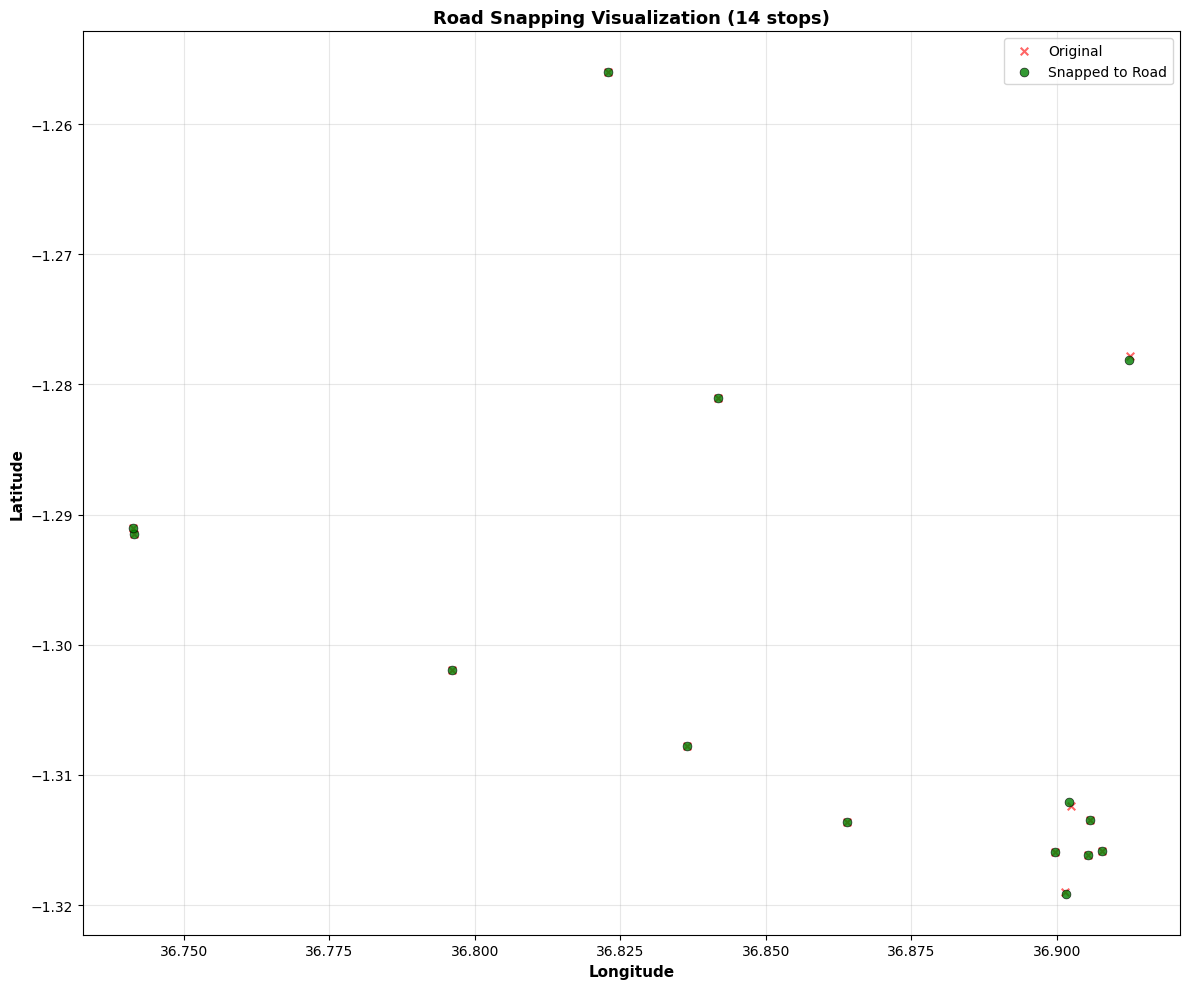

In [5]:
# Visualize snapping
fig, ax = plt.subplots(figsize=(12, 10))

# Sample for visualization
sample_size = min(200, len(selected_candidates))
sample = selected_candidates.sample(sample_size)

# Original positions
ax.scatter(sample['lon_original'], sample['lat_original'], 
          c='red', s=30, alpha=0.6, label='Original', marker='x', zorder=3)

# Snapped positions
ax.scatter(sample['lon'], sample['lat'], 
          c='green', s=40, alpha=0.8, label='Snapped to Road', marker='o', 
          edgecolors='black', linewidth=0.5, zorder=4)

# Draw snap lines
for idx, row in sample.iterrows():
    if row['snap_distance'] is not None and row['snap_distance'] < 50:
        ax.plot([row['lon_original'], row['lon']], 
               [row['lat_original'], row['lat']], 
               'gray', alpha=0.2, linewidth=0.8, zorder=2)

ax.set_xlabel('Longitude', fontweight='bold', fontsize=11)
ax.set_ylabel('Latitude', fontweight='bold', fontsize=11)
ax.set_title(f'Road Snapping Visualization ({sample_size} stops)', 
            fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/home/dataopske/Desktop/jav/data/plots/road_snapping_visualization.png', dpi=300, bbox_inches='tight')
print("\nSaved visualization to road_snapping_visualization.png")
plt.show()

> This indicates that many candidate stops lie in areas with sparse or imperfect OSM road coverage, which will be important to consider during route extension.


### v. Identifying Routes Serving Target Wards

This step determines which existing GTFS routes currently pass through the selected underserved or severely underserved wards.

We do this by:
- Listing GTFS stops located in the target wards  
- Matching those stops to trips via `stop_times`  
- Extracting the corresponding `route_id`s  

The resulting list shows all routes that already serve these priority areas, along with their basic route information.  
These routes form the baseline for evaluating extension opportunities.

In [6]:
# Cell 4: Get routes serving these wards
# Join stops with stop_times to get routes
stop_times = feed.stop_times.copy()
routes = feed.routes.copy()
trips = feed.trips.copy()

# Get stops in target wards (from your main df with ward info)
ward_stops = df[df['ward'].isin(target_wards)]['stop_id'].unique()

# Find which routes serve these wards
routes_in_wards = stop_times[
    stop_times['stop_id'].isin(ward_stops)
].merge(trips[['trip_id', 'route_id']], on='trip_id')['route_id'].unique()

print(f"Found {len(routes_in_wards)} routes serving target wards")

# Get route details
ward_routes = routes[routes['route_id'].isin(routes_in_wards)].copy()
print(f"\nRoutes in target wards:")
print(ward_routes[['route_id', 'route_short_name', 'route_long_name']].head(10))

Found 74 routes serving target wards

Routes in target wards:
       route_id route_short_name  \
0   10000107D11             107D   
9   20000004511              45K   
10  20000004512              45G   
12  20000145011              145   
13  20000237011              237   
14  20100010011              100   
15  20100012011              120   
16  20100012111              121   
17  20100100A11             100A   
18  20101007700             0027   

                                      route_long_name  
0                                         Ruaka-Ruiru  
9                   Odeon-Pangani-Roysabu-Githurai-KU  
10                Munyu Road-Pangani-Roysabu-Githurai  
12      Munyu Road-Pangani-Roysambu-Githurai-KU-Ruiru  
13  Munyu Road-Pangani-Roysabu-Githurai-KU-Ruiru-J...  
14  O.T.C-Pangani-Muthaiga Roundabout-Kiambu Road-...  
15  Kaka-Pangani-Muthaiga Roundabout-Kiambu Road-K...  
16   Kaka-Pangani-Muthaiga Roundabout-Kiambu Road-...  
17  Ngara-Pangani-Muthaiga Roundabout

### vi. Building Route Geometries

This step constructs an ordered list of stops for each route serving the target wards.  
For each route, we:

1. Select one representative trip.  
2. Extract its stops in **stop_sequence** order.  
3. Attach latitude and longitude for spatial processing.

The result is a dictionary mapping each route to its ordered stop coordinates.  
These geometries will be used later for mapping routes, measuring distances, and identifying where new candidate stops could be inserted.

In [7]:
# Cell 5: Build route geometries (ordered stop sequences)
def get_route_stops_ordered(route_id, feed):
    """Get ordered stops for a route"""
    # Get all trips for this route
    route_trips = feed.trips[feed.trips['route_id'] == route_id]['trip_id'].head(1).values
    
    if len(route_trips) == 0:
        return None
    
    # Get stop sequence for first trip (representative)
    trip_stops = feed.stop_times[
        feed.stop_times['trip_id'] == route_trips[0]
    ].sort_values('stop_sequence')
    
    # Merge with stop coordinates
    trip_stops = trip_stops.merge(
        feed.stops[['stop_id', 'stop_lat', 'stop_lon']], 
        on='stop_id'
    )
    
    return trip_stops[['stop_id', 'stop_sequence', 'stop_lat', 'stop_lon']]

# Build route geometries
route_geometries = {}

for route_id in routes_in_wards:
    stops = get_route_stops_ordered(route_id, feed)
    if stops is not None and len(stops) > 1:
        route_geometries[route_id] = stops

print(f"Built geometries for {len(route_geometries)} routes")
print(f"\nSample route stops:")
sample_route = list(route_geometries.keys())[0]
print(route_geometries[sample_route].head())

Built geometries for 74 routes

Sample route stops:
   stop_id  stop_sequence  stop_lat   stop_lon
0  0213MRY              1 -1.147669  36.959317
1  0100OOA              2 -1.149789  36.948829
2  0100AWA              3 -1.149612  36.947408
3  0100TPS              4 -1.149687  36.945525
4  0100OTN              5 -1.150637  36.942590


### vii. Matching Candidate Stops to Nearby Routes

Here we identify which candidate stops lie close enough to existing routes to be considered for potential extensions.  
For each route geometry:

- A KD-Tree is built using the ordered stop coordinates.  
- Each candidate stop is checked for proximity within a **500 m buffer**.  
- Candidates within this distance are recorded along with:
  - Their stop ID  
  - The nearest point on the route  
  - The distance to the route  

This produces a dictionary mapping each route to the candidate stops that fall within reach of its current alignment.  
These matches form the basis for evaluating where and how each route can be extended.


In [8]:
# Cell 6: Match candidates to routes (spatial proximity)
def find_candidates_near_route(route_stops, candidates_df, buffer_meters=500):
    """Find candidate stops within buffer of route"""
    # Route coordinates
    route_coords = route_stops[['stop_lat', 'stop_lon']].values
    route_tree = cKDTree(route_coords)
    
    # Candidate coordinates
    cand_coords = candidates_df[['lat', 'lon']].values
    
    # Find candidates within buffer (approx degrees)
    buffer_degrees = buffer_meters / 111000  # rough conversion
    
    matches = []
    for i, (lat, lon) in enumerate(cand_coords):
        distances, indices = route_tree.query([lat, lon], k=1)
        
        if distances < buffer_degrees:
            # Find best insertion point (between which stops)
            nearest_stop_idx = indices
            
            matches.append({
                'candidate_idx': i,
                'candidate_id': candidates_df.iloc[i]['stop_id'],
                'nearest_route_stop_idx': nearest_stop_idx,
                'distance_meters': distances * 111000
            })
    
    return pd.DataFrame(matches)

# Match candidates to each route
route_candidate_matches = {}

for route_id, route_stops in route_geometries.items():
    matches = find_candidates_near_route(route_stops, selected_candidates, buffer_meters=500)
    
    if len(matches) > 0:
        route_candidate_matches[route_id] = matches

print(f"Matched candidates to {len(route_candidate_matches)} routes")
print(f"\nSample matches for route {list(route_candidate_matches.keys())[0]}:")
print(route_candidate_matches[list(route_candidate_matches.keys())[0]].head())

Matched candidates to 27 routes

Sample matches for route 20104003910:
   candidate_idx                candidate_id  nearest_route_stop_idx  \
0              9   CANDIDATE_Pipeline Ward_0                      31   
1             13  CANDIDATE_Embakasi Ward_32                      31   

   distance_meters  
0       443.902543  
1       469.689426  


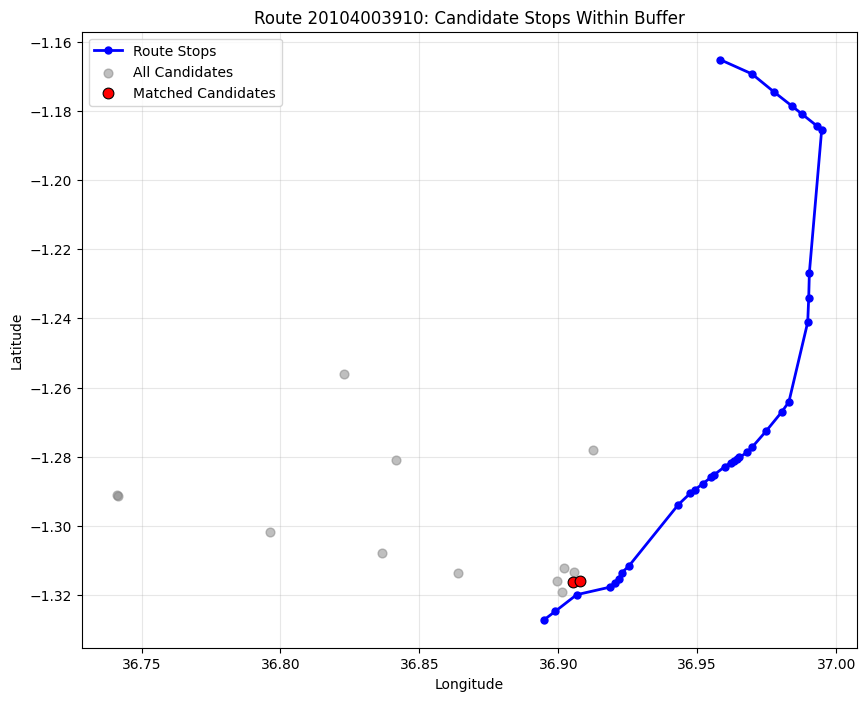

In [9]:
# Visualization for route–candidate matches
import matplotlib.pyplot as plt

def plot_route_with_candidates(route_id, route_stops, candidates, matches):
    plt.figure(figsize=(10, 8))
    
    # Plot route geometry
    plt.plot(
        route_stops['stop_lon'],
        route_stops['stop_lat'],
        '-o',
        color='blue',
        markersize=5,
        linewidth=2,
        label='Route Stops'
    )
    
    # Plot all candidates
    plt.scatter(
        candidates['lon'],
        candidates['lat'],
        c='gray',
        s=40,
        alpha=0.5,
        label='All Candidates'
    )
    
    # Highlight matched candidates
    matched_ids = matches['candidate_id'].values
    matched_points = candidates[candidates['stop_id'].isin(matched_ids)]
    
    plt.scatter(
        matched_points['lon'],
        matched_points['lat'],
        c='red',
        s=60,
        edgecolors='black',
        linewidths=0.8,
        label='Matched Candidates'
    )
    
    plt.title(f"Route {route_id}: Candidate Stops Within Buffer")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Example visualization for first matched route
first_route = list(route_candidate_matches.keys())[0]

plot_route_with_candidates(
    first_route,
    route_geometries[first_route],
    selected_candidates,
    route_candidate_matches[first_route]
)


**How Route–Candidate Matching Works**

For each bus route, we want to find which candidate stops lie close enough to the existing alignment to be realistic extension points.  
The idea is simple: if a candidate stop is geographically near the route, then the route can be extended or slightly deviated to serve it.

Here's how the matching process works:

1. **Represent each route as an ordered list of stops.**  
   Using GTFS `stop_times`, we extract the stop sequence for a representative trip.  
   This gives us the actual path the bus follows.

2. **Convert the route stops into a fast spatial index.**  
   A KD-Tree is built from the latitude/longitude coordinates of the route stops.  
   This allows us to quickly find the closest point on the route to any candidate stop.

3. **For each candidate stop, find its nearest route stop.**  
   We query the KD-Tree to compute the distance between the candidate and the closest point on the route.  
   If this distance is within a defined buffer (e.g., 500 meters), we consider the stop “near” the route.

4. **Record the match.**  
   For each matched candidate stop, we store:
   - The candidate ID  
   - The nearest route stop index  
   - The distance between the candidate and the route  

5. **Produce a per-route list of nearby candidates.**  
   After processing all candidates and all routes, we end up with a mapping:  
   **route_id → list of candidate stops that are spatially close.**

This approach gives us a practical way to identify where existing routes could be extended to reach high-quality, high-demand GNN-predicted locations without major realignment.

### viii. Generating Route Extension Variants

Here we create possible extension options (“variants”) for each route that has nearby candidate stops.  
The idea is to explore realistic modifications without fully redesigning the route.

For each route:

1. **We sort matched candidate stops by their GNN quality score**, ensuring that the most promising locations are considered first.

2. **We generate up to three variants**, each adding:
   - **Variant A:** the top 1 candidate stop  
   - **Variant B:** the top 2 candidate stops  
   - **Variant C:** the top 3 candidate stops  

3. **Each variant stores**:
   - New stop IDs  
   - Their coordinates  
   - Their predicted quality scores  
   - Population served within 500 m  

These variants represent practical, incrementally larger route extensions that planners can evaluate.  
The final output aggregates all variants into a single dataframe for ranking and comparison.

In [10]:
# Cell 7: Generate route variants
def generate_route_variants(route_id, route_stops, matches, candidates_df, max_variants=5):
    """Generate route variants by adding 1-3 new stops"""
    variants = []
    
    # Get matched candidates sorted by quality
    matched_cands = matches.merge(
        candidates_df.reset_index(),
        left_on='candidate_idx',
        right_index=True
    ).sort_values('gnn_probability', ascending=False)
    
    if len(matched_cands) == 0:
        return []
    
    # Variant 1: Add top 1 candidate
    if len(matched_cands) >= 1:
        variants.append({
            'route_id': route_id,
            'variant_id': f"{route_id}_A",
            'new_stops': [matched_cands.iloc[0]['candidate_id']],
            'new_stop_coords': [(matched_cands.iloc[0]['lat'], matched_cands.iloc[0]['lon'])],
            'quality_scores': [matched_cands.iloc[0]['gnn_probability']],
            'pop_served': [matched_cands.iloc[0]['pop_within_500m']]
        })
    
    # Variant 2: Add top 2 candidates
    if len(matched_cands) >= 2:
        variants.append({
            'route_id': route_id,
            'variant_id': f"{route_id}_B",
            'new_stops': matched_cands.iloc[:2]['candidate_id'].tolist(),
            'new_stop_coords': list(zip(matched_cands.iloc[:2]['lat'], matched_cands.iloc[:2]['lon'])),
            'quality_scores': matched_cands.iloc[:2]['gnn_probability'].tolist(),
            'pop_served': matched_cands.iloc[:2]['pop_within_500m'].tolist()
        })
    
    # Variant 3: Add top 3 candidates
    if len(matched_cands) >= 3:
        variants.append({
            'route_id': route_id,
            'variant_id': f"{route_id}_C",
            'new_stops': matched_cands.iloc[:3]['candidate_id'].tolist(),
            'new_stop_coords': list(zip(matched_cands.iloc[:3]['lat'], matched_cands.iloc[:3]['lon'])),
            'quality_scores': matched_cands.iloc[:3]['gnn_probability'].tolist(),
            'pop_served': matched_cands.iloc[:3]['pop_within_500m'].tolist()
        })
    
    return variants[:max_variants]

# Generate variants for all routes
all_variants = []

for route_id, matches in route_candidate_matches.items():
    if route_id in route_geometries:
        variants = generate_route_variants(
            route_id, 
            route_geometries[route_id], 
            matches, 
            selected_candidates,
            max_variants=3
        )
        all_variants.extend(variants)

variants_df = pd.DataFrame(all_variants)
print(f"Generated {len(variants_df)} route variants")
print(f"\nSample variants:")
print(variants_df.head())

Generated 44 route variants

Sample variants:
      route_id     variant_id  \
0  20104003910  20104003910_A   
1  20104003910  20104003910_B   
2  30800002811  30800002811_A   
3  30007004111  30007004111_A   
4  30600017A11  30600017A11_A   

                                           new_stops  \
0                        [CANDIDATE_Pipeline Ward_0]   
1  [CANDIDATE_Pipeline Ward_0, CANDIDATE_Embakasi...   
2                         [CANDIDATE_Airbase Ward_4]   
3                         [CANDIDATE_Airbase Ward_4]   
4                  [CANDIDATE_Upper Savanna Ward_26]   

                                     new_stop_coords           quality_scores  \
0        [(-1.3161611738040933, 36.905281581554746)]              [0.6764846]   
1  [(-1.3161611738040933, 36.905281581554746), (-...  [0.6764846, 0.36954564]   
2         [(-1.2810413913991752, 36.84171959730968)]             [0.51157755]   
3         [(-1.2810413913991752, 36.84171959730968)]             [0.51157755]   
4            

### ix. Scoring Route Extension Variants

This step evaluates each route variant using a composite scoring system.  
The goal is to quantify how beneficial each extension would be based on population coverage, equity impact, and operational factors.

Each variant is scored using four components:

1. **Coverage Score**  
   Measures how many new people the added stops would serve.  
   Higher coverage → higher score.

2. **Equity Score**  
   Rewards variants that add stops in **underserved** or **severely underserved** wards.  
   These areas receive stronger multipliers to prioritize equity-focused expansion.

3. **Speed Score** *(placeholder for future enhancement)*  
   Represents how the extension may affect operational speed.

4. **Congestion Score** *(placeholder)*  
   Accounts for potential delays due to traffic patterns.

**N/B:Equity Multiplier (Fairness in Transit Planning)**

The **Equity Multiplier** is a core part of the scoring system that ensures route extensions do not only benefit already well-served or high-demand areas.  
Each candidate stop is assigned a multiplier based on the equity status of its ward:

- **2.0×**: *Severely underserved wards*
- **1.5×**: *Underserved wards*
- **1.0×**: *Adequately served wards*
- **0.8×**: *Well-served wards*

This multiplier boosts the contribution of new stops added in disadvantaged areas.  
It influences both spatial coverage and the final variant ranking, ensuring the model systematically favors improvements in places where transit access gaps are most severe.  
In short, the Equity Multiplier keeps the recommendations aligned with **inclusive mobility**, not just efficiency.


These components are combined into a **final weighted score**, giving a balanced view of the extension’s overall value.  
The results are appended to the variants dataframe, allowing us to rank and compare all route extension options.

In [11]:
# Cell 8 (REPLACE): Score route variants
def score_route_variant(variant, weight_coverage=0.50, weight_equity=0.20, 
                       weight_speed=0.15, weight_congestion=0.15):
    """Score a route variant"""
    
    # Coverage score: total new population served
    total_pop = sum(variant['pop_served'])
    coverage_score = total_pop / 150000  # normalize (max ~150k)
    coverage_score = min(coverage_score, 1.0)
    
    # Equity score: check ward categories of new stops
    new_stop_ids = variant['new_stops']
    ward_cats = []
    
    for sid in new_stop_ids:
        match = selected_candidates[selected_candidates['stop_id'] == sid]
        if len(match) > 0:
            ward_cats.append(match['ward_category'].values[0])
    
    # Equity multiplier
    equity_multipliers = {
        'severely_underserved': 2.0,
        'underserved': 1.5,
        'adequately_served': 1.0,
        'well_served': 0.8
    }
    
    avg_multiplier = np.mean([equity_multipliers.get(cat, 1.0) for cat in ward_cats]) if ward_cats else 1.0
    equity_score = avg_multiplier / 2.0  # normalize to 0-1
    
    # Speed score: use existing route average (placeholder)
    speed_score = 0.5  # placeholder - you can enhance this later
    
    # Congestion score: 1 - (congestion_pct / 100)
    congestion_score = 0.6  # placeholder - you can enhance this later
    
    # Final score
    final_score = (
        weight_coverage * coverage_score * avg_multiplier +  # Coverage with equity boost
        weight_equity * equity_score +
        weight_speed * speed_score +
        weight_congestion * congestion_score
    )
    
    return {
        'coverage_score': coverage_score,
        'equity_score': equity_score,
        'equity_multiplier': avg_multiplier,
        'speed_score': speed_score,
        'congestion_score': congestion_score,
        'final_score': final_score,
        'total_pop_served': total_pop
    }

# Score all variants
scores = []
for idx, variant in variants_df.iterrows():
    score = score_route_variant(variant)  # Removed df argument
    scores.append(score)

scores_df = pd.DataFrame(scores)
variants_df = pd.concat([variants_df, scores_df], axis=1)

print("Scored all variants")
print(f"\nScore statistics:")
print(variants_df[['final_score', 'total_pop_served', 'equity_multiplier']].describe())

Scored all variants

Score statistics:
       final_score  total_pop_served  equity_multiplier
count    44.000000         44.000000          44.000000
mean      0.412095      18149.204545           1.545455
std       0.047658       9627.510064           0.123805
min       0.339930       4986.000000           1.500000
25%       0.382315       8719.000000           1.500000
50%       0.407855      17514.000000           1.500000
75%       0.438790      23914.000000           1.500000
max       0.512960      39592.000000           2.000000


### x. Aggregating Route-Level Performance Metrics

This step computes detailed operational and performance statistics for each route using all stops currently served by that route.  
By aggregating stop-level attributes, we build a clearer picture of how each route performs today.

For every route, we calculate:

- **Population Served**  
  Sum of `pop_within_500m` across all stops on the route.

- **Temporal Metrics**  
  - Trips per hour  
  - Total trips per day  
  - Average headway  
  - Service span  

- **Performance Metrics** *(population-weighted)*  
  - Average daily speed  
  - Peak speed  
  - Daily congestion percentage  
  - Peak congestion percentage  

- **Demand Metrics**  
  - Total daily trips generated  
  - Peak trips generated  
  - Demand variability (CV)

These metrics help us understand a route’s current efficiency, demand, and operational environment.  
They also provide a baseline for comparing how proposed extension variants might improve or worsen route performance.


In [12]:
# Cell 8A: Aggregate route-level temporal & performance metrics
print("="*70)
print("AGGREGATING ROUTE-LEVEL METRICS")
print("="*70)

def get_route_metrics(route_id, route_stops, df):
    """Aggregate temporal and performance metrics for a route"""
    
    # Get stop IDs for this route
    stop_ids = route_stops['stop_id'].values
    
    # Filter main df for these stops
    route_stop_data = df[df['stop_id'].isin(stop_ids)]
    
    if len(route_stop_data) == 0:
        return None
    
    # Aggregate metrics (weighted by population)
    total_pop = route_stop_data['pop_within_500m'].sum()
    
    if total_pop == 0:
        return None
    
    # Temporal metrics
    trips_per_hour = route_stop_data['trips_per_1k_pop_per_hour'].mean()
    trips_per_day = route_stop_data['trips_per_day'].sum()
    avg_headway = route_stop_data['avg_headway_minutes'].mean()
    service_span = route_stop_data['service_span_hours'].mean()
    
    # Performance metrics (population-weighted)
    weights = route_stop_data['pop_within_500m'] / total_pop
    
    avg_speed = (route_stop_data['avg_speed_daily'] * weights).sum()
    avg_speed_peak = (route_stop_data['avg_speed_peak'] * weights).sum()
    congestion_pct = (route_stop_data['congestion_pct_daily'] * weights).sum()
    congestion_peak = (route_stop_data['congestion_pct_peak'] * weights).sum()
    
    # Demand metrics (from traffic model)
    trip_count_daily = route_stop_data['trip_count_daily'].sum()
    trip_count_peak = route_stop_data['trip_count_peak'].sum()
    demand_variability = route_stop_data['demand_variability_cv'].mean()
    
    return {
        'route_id': route_id,
        'total_pop_served': total_pop,
        'num_stops': len(route_stop_data),
        
        # Temporal
        'trips_per_1k_pop_per_hour': trips_per_hour,
        'trips_per_day': trips_per_day,
        'avg_headway_minutes': avg_headway,
        'service_span_hours': service_span,
        
        # Performance
        'avg_speed_daily': avg_speed,
        'avg_speed_peak': avg_speed_peak,
        'congestion_pct_daily': congestion_pct,
        'congestion_pct_peak': congestion_peak,
        
        # Demand
        'trip_count_daily': trip_count_daily,
        'trip_count_peak': trip_count_peak,
        'demand_variability_cv': demand_variability
    }

# Aggregate for all routes
route_metrics_list = []

for route_id, route_stops in route_geometries.items():
    metrics = get_route_metrics(route_id, route_stops, df)
    if metrics:
        route_metrics_list.append(metrics)

route_metrics_df = pd.DataFrame(route_metrics_list)

print(f"\nAggregated metrics for {len(route_metrics_df)} routes")
print("\nSample route metrics:")
print(route_metrics_df.head())

print("\nMetric statistics:")
print(route_metrics_df[['trips_per_1k_pop_per_hour', 'avg_speed_daily', 
                        'congestion_pct_daily', 'trip_count_daily']].describe())

AGGREGATING ROUTE-LEVEL METRICS

Aggregated metrics for 74 routes

Sample route metrics:
      route_id  total_pop_served  num_stops  trips_per_1k_pop_per_hour  \
0  10000107D11            130854         38                  12.052375   
1  20801002511            790362         22                  32.617176   
2  20104003910             68890         34                  18.026301   
3  20901043011            237152         11                  26.097444   
4  21100004411            291658         21                  31.831206   

   trips_per_day  avg_headway_minutes  service_span_hours  avg_speed_daily  \
0             44          1389.473684            0.052632        17.996073   
1             87           960.793388            0.227273        17.713401   
2             34          1440.000000            0.000000        17.565689   
3             66           585.454545            0.454545        17.684658   
4            153           353.387755            0.476190        17.822789  

### xi. Comprehensive Scoring of Route Variants

This step upgrades the earlier scoring system into a more complete evaluation framework that considers **spatial**, **temporal**, **performance**, and **demand-based** factors.  
The goal is to estimate the true impact of each route extension variant using a richer set of signals.

Each variant is evaluated using the following components:

1. **Spatial Coverage (30%)**  
   Measures the total population reached by the newly added stops, with a cap for normalization.

2. **Equity Multiplier (used in multiple components)**  
   Prioritizes extensions into underserved and severely underserved wards.  
   Higher equity → stronger weight applied across scores.

3. **Temporal Equity (25%)**  
   Rewards variants that add stops in areas that currently have low service frequency.  
   This helps identify extensions that meaningfully improve transit availability.

4. **Performance Score (20%)**  
   Combines normalized route speed and congestion:  
   - Higher speed improves the score  
   - Higher congestion reduces it  
   Weighted 60/40 in favor of speed.

5. **Demand Matching (15%)**  
   Considers both:
   - Existing route-level demand  
   - Demand potential of the new candidate stops  
   Higher alignment with demand leads to higher scores.

6. **Extra Equity Weight (10%)**  
   Provides an explicit bonus to prioritize socially important extensions.

All components are blended into a **final composite score** for each variant.  
These scores allow clear comparison and ranking of route extension options, enabling more informed decision-making.

In [13]:
# Cell 8B: Calculate comprehensive scores for route variants
from sklearn.preprocessing import MinMaxScaler

print("="*70)
print("CALCULATING COMPREHENSIVE SCORES")
print("="*70)

# Normalize route-level metrics (0-1 scale)
scaler = MinMaxScaler()

normalized_metrics = route_metrics_df.copy()
metrics_to_normalize = [
    'trips_per_1k_pop_per_hour',
    'avg_speed_daily',
    'congestion_pct_daily',
    'trip_count_daily'
]

normalized_metrics[metrics_to_normalize] = scaler.fit_transform(
    route_metrics_df[metrics_to_normalize]
)

# Create lookup dictionary
route_metrics_dict = normalized_metrics.set_index('route_id').to_dict('index')

def score_variant_comprehensive(variant, selected_candidates, route_metrics_dict, df):
    """
    Comprehensive scoring with spatial + temporal + performance + demand
    
    Weights:
    - Coverage (spatial): 30%
    - Temporal equity: 25%
    - Performance (speed): 20%
    - Demand matching: 15%
    - Equity boost: 10%
    """
    
    # === 1. SPATIAL COVERAGE SCORE ===
    total_pop = sum(variant['pop_served'])
    coverage_score = min(total_pop / 150000, 1.0)  # Normalize to max 150k
    
    # === 2. EQUITY MULTIPLIER ===
    new_stop_ids = variant['new_stops']
    ward_cats = []
    
    for sid in new_stop_ids:
        match = selected_candidates[selected_candidates['stop_id'] == sid]
        if len(match) > 0:
            ward_cats.append(match['ward_category'].values[0])
    
    equity_multipliers = {
        'severely_underserved': 2.0,
        'underserved': 1.5,
        'adequately_served': 1.0,
        'well_served': 0.8
    }
    
    avg_equity_mult = np.mean([equity_multipliers.get(cat, 1.0) for cat in ward_cats]) if ward_cats else 1.0
    
    # === 3. TEMPORAL EQUITY SCORE ===
    # Get baseline route temporal metrics
    route_id = variant['route_id']
    base_metrics = route_metrics_dict.get(route_id, {})
    
    # Current temporal service level (normalized 0-1)
    current_temporal = base_metrics.get('trips_per_1k_pop_per_hour', 0.5)
    
    # Calculate new stops' temporal potential
    new_stop_temporal = []
    for sid in new_stop_ids:
        stop_data = df[df['stop_id'] == sid]
        if len(stop_data) > 0:
            # New stops inherit route's service frequency
            # Score by how underserved the area is
            stop_trips = stop_data.iloc[0].get('trips_per_1k_pop_per_hour', 0)
            # Invert: lower current service = higher score
            temporal_need = 1.0 - min(stop_trips / 10.0, 1.0)  # Normalize to max 10
            new_stop_temporal.append(temporal_need)
    
    # Temporal equity score: prioritize adding stops to low-service areas
    if new_stop_temporal:
        temporal_equity_score = np.mean(new_stop_temporal)
    else:
        temporal_equity_score = 0.5
    
    # === 4. PERFORMANCE SCORE (Speed + Congestion) ===
    # Get route performance
    avg_speed_norm = base_metrics.get('avg_speed_daily', 0.5)
    congestion_norm = base_metrics.get('congestion_pct_daily', 0.5)
    
    # Speed score: higher is better
    speed_score = avg_speed_norm
    
    # Congestion score: lower congestion is better
    congestion_score = 1.0 - congestion_norm
    
    # Combined performance: 60% speed, 40% congestion
    performance_score = 0.6 * speed_score + 0.4 * congestion_score
    
    # === 5. DEMAND MATCHING SCORE ===
    # How well does the route serve actual demand?
    trip_count_norm = base_metrics.get('trip_count_daily', 0.5)
    
    # Calculate demand potential of new stops
    new_stop_demand = []
    for sid in new_stop_ids:
        stop_data = df[df['stop_id'] == sid]
        if len(stop_data) > 0:
            stop_trips = stop_data.iloc[0].get('trip_count_daily', 0)
            # Normalize (typical max ~5000 trips)
            demand_norm = min(stop_trips / 5000.0, 1.0)
            new_stop_demand.append(demand_norm)
    
    if new_stop_demand:
        new_demand_score = np.mean(new_stop_demand)
    else:
        new_demand_score = 0.5
    
    # Combine: 50% existing route demand, 50% new stop potential
    demand_match_score = 0.5 * trip_count_norm + 0.5 * new_demand_score
    
    # === 6. FINAL SCORE ===
    final_score = (
        0.30 * coverage_score * avg_equity_mult +  # Spatial coverage with equity boost
        0.25 * temporal_equity_score +              # Temporal equity (serve underserved times)
        0.20 * performance_score +                  # Speed + low congestion
        0.15 * demand_match_score +                 # Match actual demand
        0.10 * (avg_equity_mult / 2.0)             # Additional equity weight
    )
    
    return {
        'coverage_score': coverage_score,
        'temporal_equity_score': temporal_equity_score,
        'performance_score': performance_score,
        'speed_score': speed_score,
        'congestion_score': congestion_score,
        'demand_match_score': demand_match_score,
        'equity_multiplier': avg_equity_mult,
        'final_score': final_score,
        'total_pop_served': total_pop
    }

# Re-score all variants with comprehensive scoring
print("Scoring variants with spatial + temporal + performance + demand...")

comprehensive_scores = []
for idx, variant in variants_df.iterrows():
    score = score_variant_comprehensive(
        variant, 
        selected_candidates, 
        route_metrics_dict,
        df
    )
    comprehensive_scores.append(score)

# Replace old scores
scores_df = pd.DataFrame(comprehensive_scores)
variants_df = variants_df.drop(columns=[col for col in variants_df.columns if col in scores_df.columns])
variants_df = pd.concat([variants_df, scores_df], axis=1)

print("\nComprehensive scoring complete!")
print("\nScore component statistics:")
print(variants_df[['coverage_score', 'temporal_equity_score', 'performance_score', 
                  'demand_match_score', 'final_score']].describe())

CALCULATING COMPREHENSIVE SCORES
Scoring variants with spatial + temporal + performance + demand...

Comprehensive scoring complete!

Score component statistics:
       coverage_score  temporal_equity_score  performance_score  \
count       44.000000              44.000000          44.000000   
mean         0.120995               0.221819           0.304368   
std          0.064183               0.241730           0.172678   
min          0.033240               0.000000           0.018080   
25%          0.058127               0.000000           0.214179   
50%          0.116760               0.198079           0.257335   
75%          0.159427               0.369337           0.401221   
max          0.263947               0.738674           0.802657   

       demand_match_score  final_score  
count           44.000000    44.000000  
mean             0.194036     0.278236  
std              0.126473     0.081517  
min              0.031614     0.139624  
25%              0.107220    

### xii. Comprehensive Scoring of Route Variants

This step upgrades the earlier scoring system into a more complete evaluation framework that considers **spatial**, **temporal**, **performance**, and **demand-based** factors.  
The goal is to estimate the true impact of each route extension variant using a richer set of signals.

Each variant is evaluated using the following components:

1. **Spatial Coverage (30%)**  
   Measures the total population reached by the newly added stops, with a cap for normalization.

2. **Equity Multiplier (used in multiple components)**  
   Prioritizes extensions into underserved and severely underserved wards.  
   Higher equity → stronger weight applied across scores.

3. **Temporal Equity (25%)**  
   Rewards variants that add stops in areas that currently have low service frequency.  
   This helps identify extensions that meaningfully improve transit availability.

4. **Performance Score (20%)**  
   Combines normalized route speed and congestion:  
   - Higher speed improves the score  
   - Higher congestion reduces it  
   Weighted 60/40 in favor of speed.

5. **Demand Matching (15%)**  
   Considers both:
   - Existing route-level demand  
   - Demand potential of the new candidate stops  
   Higher alignment with demand leads to higher scores.

6. **Extra Equity Weight (10%)**  
   Provides an explicit bonus to prioritize socially important extensions.

All components are blended into a **final composite score** for each variant.  
These scores allow clear comparison and ranking of route extension options, enabling more informed decision-making.

In [14]:
# Cell 8C: Re-rank with new comprehensive scores
variants_df = variants_df.sort_values('final_score', ascending=False)

print("="*70)
print("TOP 20 ROUTES - COMPREHENSIVE RANKING")
print("="*70)
print("Spatial (30%) + Temporal (25%) + Performance (20%) + Demand (15%) + Equity (10%)")
print("="*70)

top_20 = variants_df.head(20)

for i, (idx, row) in enumerate(top_20.iterrows(), 1):
    print(f"\n{i}. {row['variant_id']}")
    print(f"   Final Score: {row['final_score']:.3f}")
    print(f"   - Coverage: {row['coverage_score']:.3f} (pop: {row['total_pop_served']:,.0f})")
    print(f"   - Temporal Equity: {row['temporal_equity_score']:.3f}")
    print(f"   - Performance: {row['performance_score']:.3f} (speed: {row['speed_score']:.3f}, congestion: {row['congestion_score']:.3f})")
    print(f"   - Demand Match: {row['demand_match_score']:.3f}")
    print(f"   - Equity Boost: {row['equity_multiplier']:.2f}x")

# Save comprehensive recommendations
variants_df.to_csv('/home/dataopske/Desktop/jav/data/training_output/route_recommendations_comprehensive.csv', index=False)
print(f"\n\nSaved {len(variants_df)} comprehensive recommendations")

TOP 20 ROUTES - COMPREHENSIVE RANKING
Spatial (30%) + Temporal (25%) + Performance (20%) + Demand (15%) + Equity (10%)

1. 70600010211_A
   Final Score: 0.417
   - Coverage: 0.159 (pop: 23,914)
   - Temporal Equity: 0.739
   - Performance: 0.221 (speed: 0.221, congestion: 0.221)
   - Demand Match: 0.276
   - Equity Boost: 1.50x

2. 40700003311_A
   Final Score: 0.413
   - Coverage: 0.124 (pop: 18,571)
   - Temporal Equity: 0.430
   - Performance: 0.803 (speed: 0.769, congestion: 0.853)
   - Demand Match: 0.096
   - Equity Boost: 1.50x

3. 70000010311_A
   Final Score: 0.412
   - Coverage: 0.159 (pop: 23,914)
   - Temporal Equity: 0.739
   - Performance: 0.018 (speed: 0.000, congestion: 0.045)
   - Demand Match: 0.513
   - Equity Boost: 1.50x

4. 70500004W11_A
   Final Score: 0.406
   - Coverage: 0.159 (pop: 23,914)
   - Temporal Equity: 0.739
   - Performance: 0.257 (speed: 0.284, congestion: 0.217)
   - Demand Match: 0.155
   - Equity Boost: 1.50x

5. 70601000211_A
   Final Score: 0.4

**Understanding the Comprehensive Route Extension Scores**

The comprehensive ranking brings together **all major dimensions of route performance and equity impact**, giving us a well-rounded view of which route extensions offer the greatest overall benefit.

The scores now allow us to evaluate extensions from two essential perspectives:

**1. Spatial Benefits (Who and Where We Serve)**  
The spatial side of the score captures:

- **Population Coverage:**  
  How many new people the extension would reach, especially in dense or high-need areas.

- **Ward Equity Boost:**  
  Extensions into *underserved* and *severely underserved* wards receive higher multipliers, ensuring the model prioritizes socially important improvements.

Together, these spatial components tell us:
- *Which extensions reach the most people*
- *Which ones target areas currently lacking good service*
- *Where the largest geographic accessibility gains occur*

This helps planners identify **geographically impactful** route expansions.

**2. Temporal & Operational Benefits (How Well We Serve Them)**  
The temporal and performance scores reflect how extensions influence **service quality over time**:

- **Temporal Equity:**  
  Measures how much new stops help wards that currently have poor service frequency or long headways.

- **Performance Score:**  
  Combines speed and congestion, so routes that maintain good reliability score higher.

- **Demand Matching:**  
  Looks at both existing route demand and demand at new stops, ensuring extensions align with where people actually travel.

These temporal factors reveal:
- *Which extensions improve service quality where it's weakest*  
- *Which keep operational speed and reliability intact*  
- *Which align best with actual passenger demand patterns*

This highlights **service-level and operational advantages**.

**What the Combined Score Gives Us Now**

By combining spatial, temporal, performance, and demand factors, the comprehensive ranking now shows:

- **Which route extensions serve the most people**  
- **Which create the biggest equity gains**  
- **Which strengthen service where it is currently weak**  
- **Which preserve operational efficiency**  
- **Which align best with actual travel demand**

In other words, the score identifies the **most impactful**, **most equitable**, and **most operationally feasible** route extension opportunities.

This provides a balanced and actionable foundation for real-world route planning and prioritization.

### xiii. Component Analysis Visualization – Why We Plot These Scores

This visualization helps break down **why** the highest-ranking route variants scored well by showing how each component contributes to the final result. Instead of looking only at the final composite score, these plots reveal the underlying strengths and weaknesses of each candidate.

**What this section shows:**

1. **Coverage Score (Spatial Reach)**  
   - Highlights how much additional population each variant brings into the network.  
   - Large bars indicate strong geographic impact.

2. **Temporal Equity Score**  
   - Shows which variants most improve service frequency for underserved areas.  
   - Important for understanding *time-based* accessibility gaps.

3. **Performance Score (Speed + Congestion)**  
   - Indicates whether adding stops preserves route efficiency.  
   - Routes with high performance scores maintain reliability even after extension.

4. **Demand Match Score**  
   - Shows how well the extension aligns with actual travel demand.  
   - High scores mean added stops capture meaningful trip activity.

5. **Final Comprehensive Score**  
   - The weighted combination of all components.  
   - This chart shows the final ranking visually.

6. **Score Breakdown for Top 5 Variants**  
   - Displays the exact weighted contribution of each component.  
   - Makes it easy to see whether a variant ranks high because of:  
     - High spatial coverage  
     - Strong performance  
     - Strong temporal equity  
     - Good demand alignment  
     - Or a combination of factors


Saved comprehensive scoring analysis


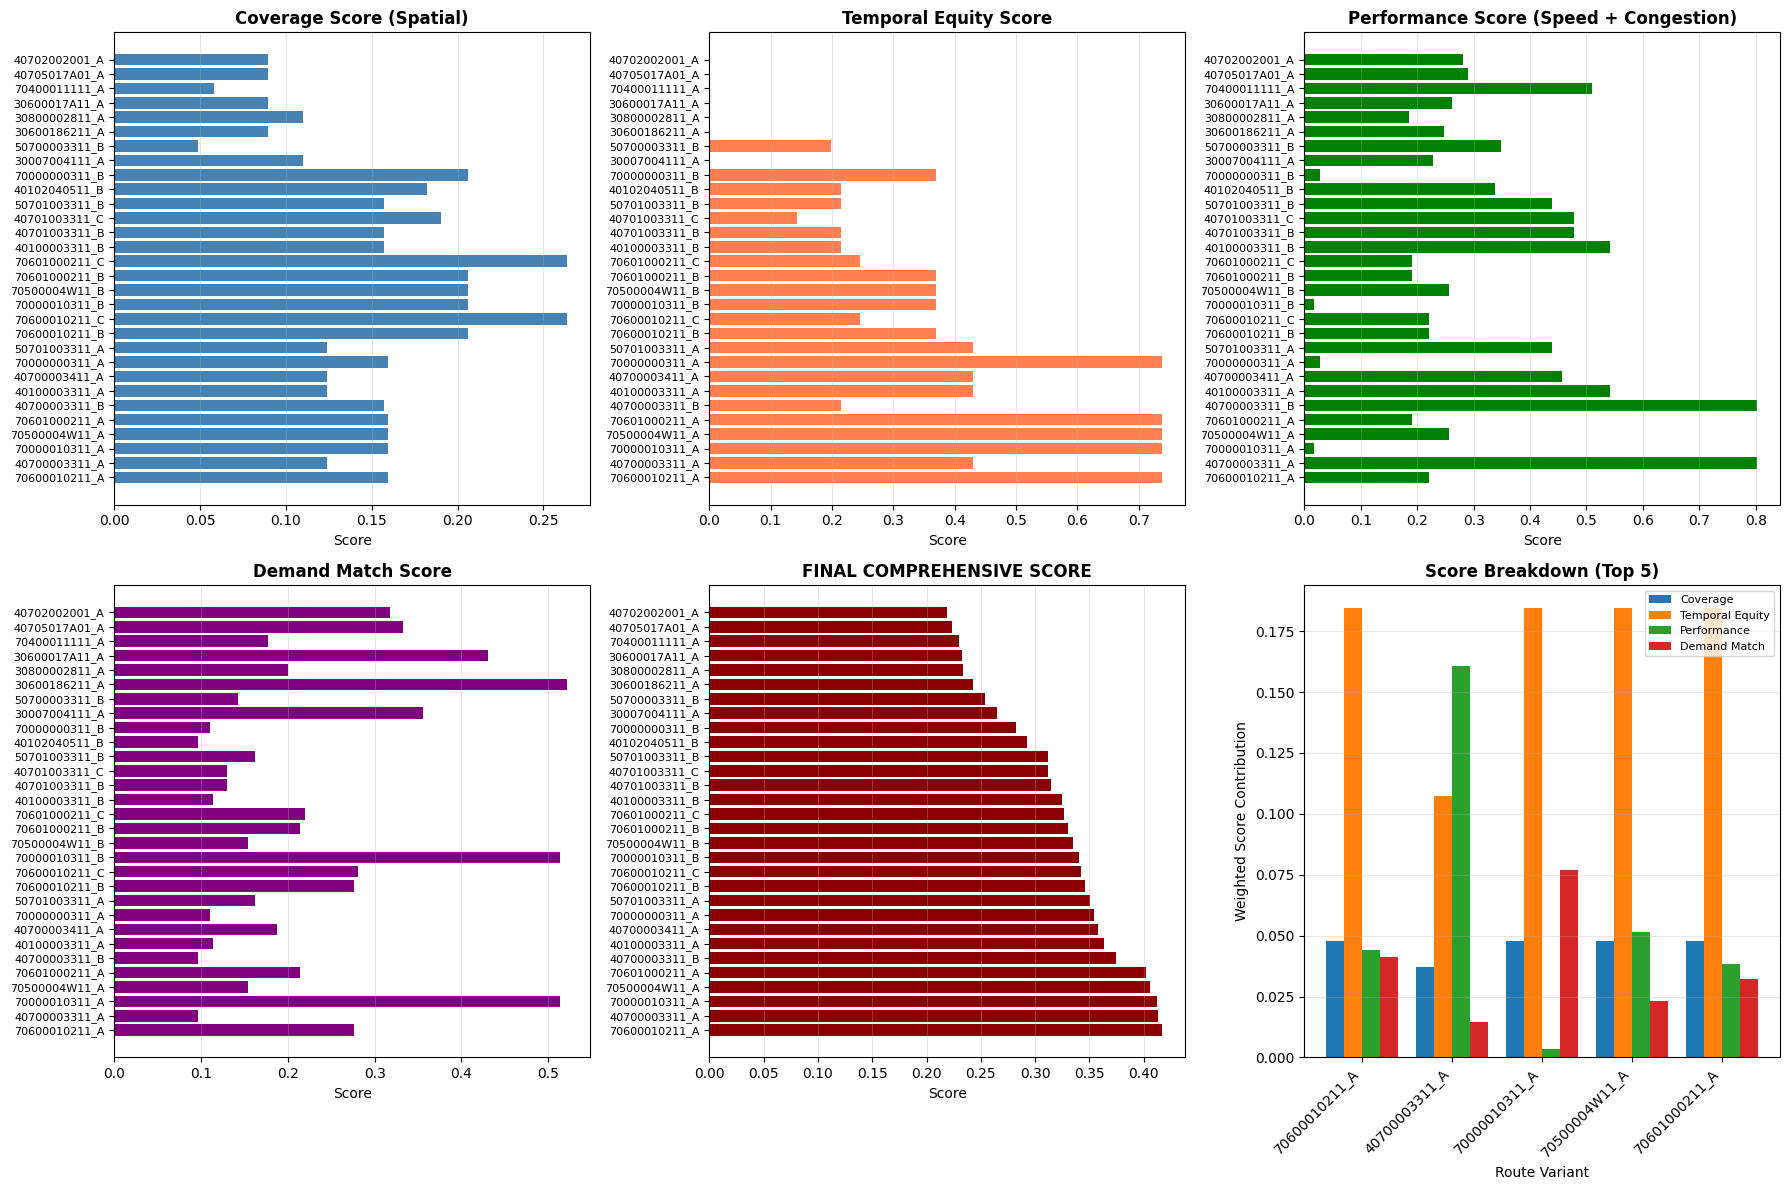

In [15]:
# Cell 8D: Component analysis visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

top_30 = variants_df.head(30)

# Coverage scores
ax = axes[0, 0]
ax.barh(range(len(top_30)), top_30['coverage_score'], color='steelblue')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Coverage Score (Spatial)', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Temporal equity
ax = axes[0, 1]
ax.barh(range(len(top_30)), top_30['temporal_equity_score'], color='coral')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Temporal Equity Score', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Performance
ax = axes[0, 2]
ax.barh(range(len(top_30)), top_30['performance_score'], color='green')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Performance Score (Speed + Congestion)', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Demand match
ax = axes[1, 0]
ax.barh(range(len(top_30)), top_30['demand_match_score'], color='purple')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Demand Match Score', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Final score
ax = axes[1, 1]
ax.barh(range(len(top_30)), top_30['final_score'], color='darkred')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('FINAL COMPREHENSIVE SCORE', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# Score components breakdown for top 5
ax = axes[1, 2]
top_5 = variants_df.head(5)
components = ['coverage_score', 'temporal_equity_score', 'performance_score', 'demand_match_score']
weights = [0.30, 0.25, 0.20, 0.15]

x = np.arange(len(top_5))
width = 0.2

for i, (comp, weight) in enumerate(zip(components, weights)):
    values = top_5[comp] * weight
    ax.bar(x + i*width, values, width, label=comp.replace('_score', '').replace('_', ' ').title())

ax.set_xlabel('Route Variant')
ax.set_ylabel('Weighted Score Contribution')
ax.set_title('Score Breakdown (Top 5)', fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(top_5['variant_id'], rotation=45, ha='right')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/home/dataopske/Desktop/jav/data/plots/comprehensive_scoring_analysis.png', dpi=300, bbox_inches='tight')
print("\nSaved comprehensive scoring analysis")
plt.show()


**Why it matters:**  
This component-level view ensures that route recommendations are interpretable. Planners can immediately identify whether a route ranks high because it truly improves coverage and equity—or whether it performs well mainly due to operational speed or demand factors. It builds transparency into how the scoring framework behaves across different dimensions.

### xiv. Final Route Variant Ranking; What This Step Delivers

This final step synthesizes **all scoring dimensions** spatial, temporal, performance, demand, and equity; to produce a **ranked list of the strongest route extension options**. By sorting variants according to their *final comprehensive score*, we surface the route configurations that meaningfully expand coverage while maintaining operational feasibility.

**What this cell accomplishes:**

- Produces a **ranked list of the top 20 highest-scoring route variants**.
- Shows key attributes for each recommendation:
  - **Number of new stops added**
  - **Total new population served**
  - **Equity multiplier** (how strongly the extension benefits underserved areas)
  - **Final weighted score**
  - **Exact candidate stop IDs** added to the route
- Provides a clear, planner-ready summary of why each variant is recommended.
- Saves the full ranking table to `route_recommendations.csv` for use in mapping tools, dashboards, or operational planning.

In [16]:
# Cell 9: Rank variants and get recommendations
# Sort by final score
variants_df = variants_df.sort_values('final_score', ascending=False)

print("="*70)
print("TOP 20 ROUTE RECOMMENDATIONS")
print("="*70)

top_20 = variants_df.head(20)

for idx, row in top_20.iterrows():
    print(f"\n{idx+1}. {row['variant_id']}")
    print(f"   New stops: {len(row['new_stops'])}")
    print(f"   Population served: {row['total_pop_served']:,.0f}")
    print(f"   Equity multiplier: {row['equity_multiplier']:.2f}x")
    print(f"   Final score: {row['final_score']:.3f}")
    print(f"   Stops: {row['new_stops']}")

# Save recommendations
variants_df.to_csv('/home/dataopske/Desktop/jav/data/training_output/route_recommendations.csv', index=False)
print(f"\n Saved {len(variants_df)} /home/dataopske/Desktop/jav/data/training_output/recommendations to route_recommendations.csv")

TOP 20 ROUTE RECOMMENDATIONS

39. 70600010211_A
   New stops: 1
   Population served: 23,914
   Equity multiplier: 1.50x
   Final score: 0.417
   Stops: ['CANDIDATE_Gatina Ward_15']

10. 40700003311_A
   New stops: 1
   Population served: 18,571
   Equity multiplier: 1.50x
   Final score: 0.413
   Stops: ['CANDIDATE_Imara Daima Ward_25']

42. 70000010311_A
   New stops: 1
   Population served: 23,914
   Equity multiplier: 1.50x
   Final score: 0.412
   Stops: ['CANDIDATE_Gatina Ward_15']

37. 70500004W11_A
   New stops: 1
   Population served: 23,914
   Equity multiplier: 1.50x
   Final score: 0.406
   Stops: ['CANDIDATE_Gatina Ward_15']

31. 70601000211_A
   New stops: 1
   Population served: 23,914
   Equity multiplier: 1.50x
   Final score: 0.402
   Stops: ['CANDIDATE_Gatina Ward_15']

11. 40700003311_B
   New stops: 2
   Population served: 23,557
   Equity multiplier: 1.50x
   Final score: 0.374
   Stops: ['CANDIDATE_Imara Daima Ward_25', 'CANDIDATE_Pipeline Ward_3']

8. 4010000331

**Why it matters:**  
This step is the culmination of the entire route-extension workflow. It translates the GNN’s spatial intelligence, GTFS insights, and real-world transport performance metrics into **structured, evidence-based recommendations**. The result is a prioritized shortlist of extensions that maximize impact across Nairobi’s transit network, ready for further validation, visualization, or integration into future optimization models.

### xv. High-Level Visualization of Route Recommendations

This section presents **summary-level visualizations** that complement the earlier component-level diagnostics.  
While previous plots explained *why* variants performed well (coverage, temporal equity, performance, demand), these charts provide a **planner-friendly overview** of the overall results.

**What this cell adds:**

1. **Top 10 Route Variants by Final Score**  
   A clean ranking that highlights the strongest proposals after all weighting is applied.

2. **Population Served by Each Top Variant**  
   Shows the real-world impact of each recommendation, independent of other scoring components.

3. **Distribution of All Final Scores**  
   A histogram revealing whether strong variants are rare, common, or tightly clustered.

4. **Distribution of Equity Multipliers**  
   Illustrates how much equity uplift the recommendations provide across the entire system.


 /home/dataopske/Desktop/jav/data/plots/Saved analysis to route_recommendations_analysis.png


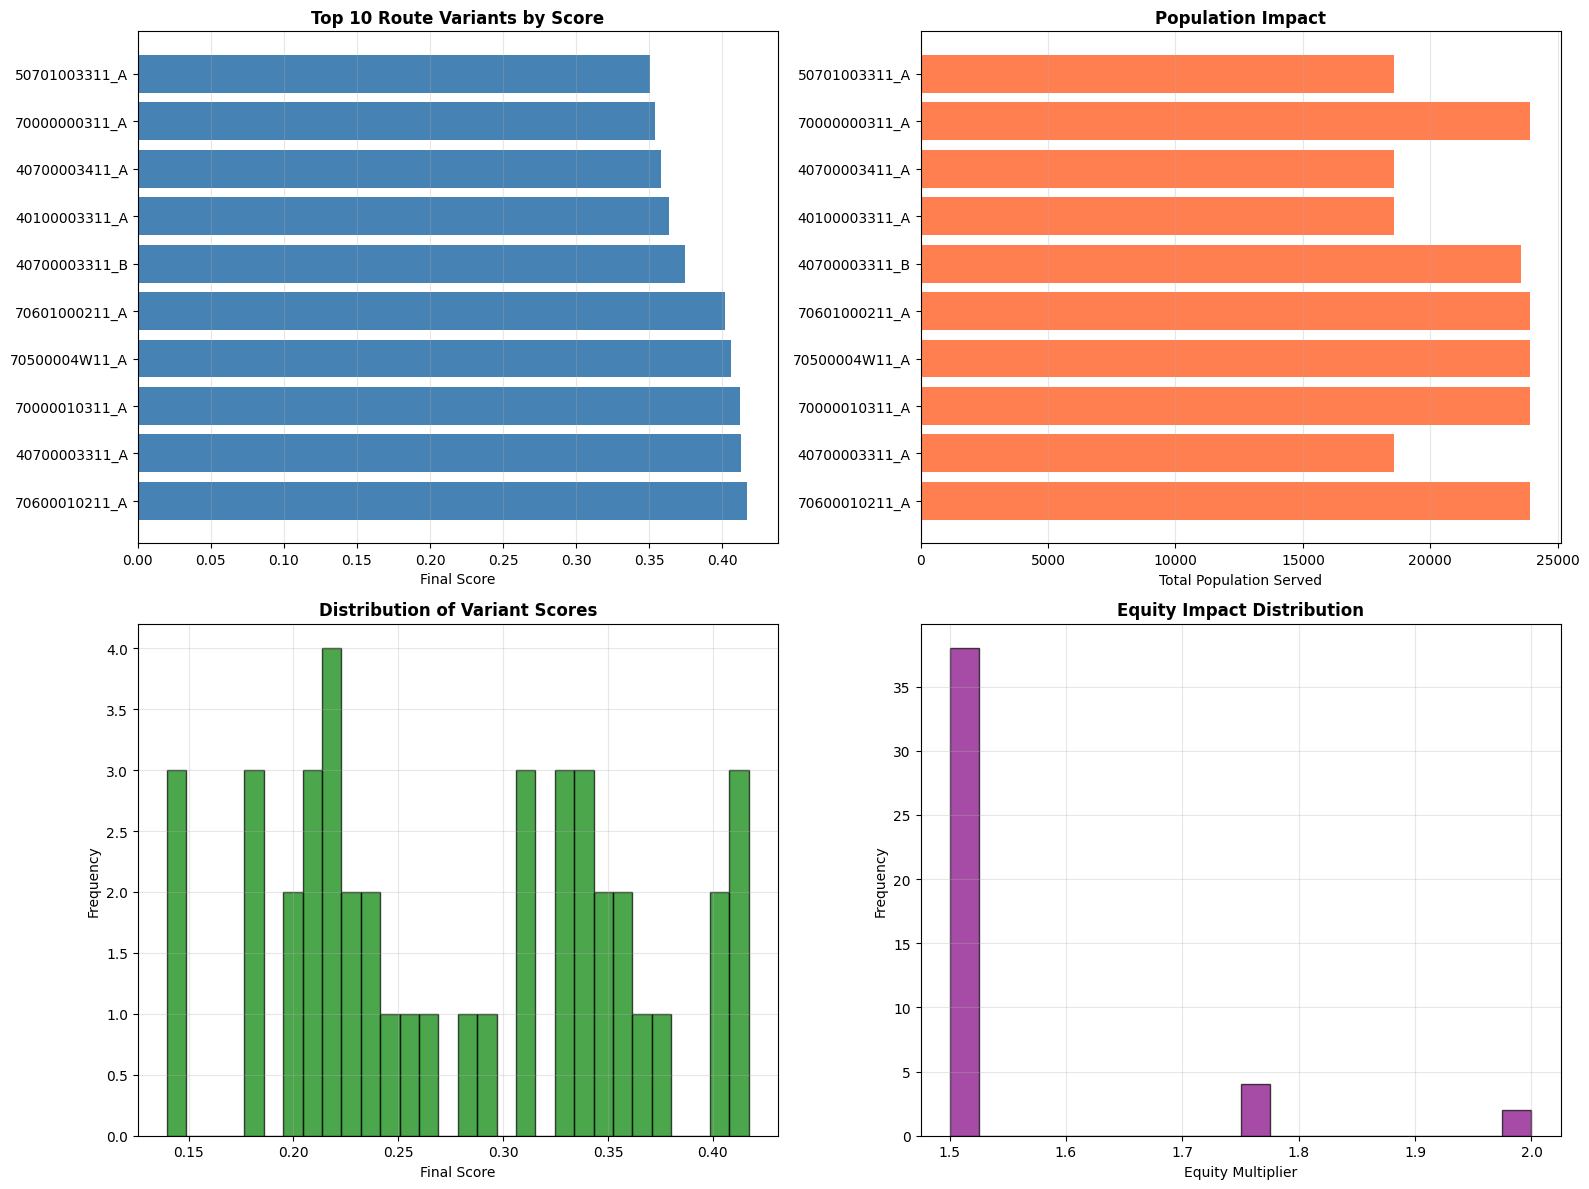

In [17]:
# Cell 10: Visualize top recommendations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 by score
ax = axes[0, 0]
top_10 = variants_df.head(10)
ax.barh(range(len(top_10)), top_10['final_score'], color='steelblue')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['variant_id'])
ax.set_xlabel('Final Score')
ax.set_title('Top 10 Route Variants by Score', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Population served
ax = axes[0, 1]
ax.barh(range(len(top_10)), top_10['total_pop_served'], color='coral')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['variant_id'])
ax.set_xlabel('Total Population Served')
ax.set_title('Population Impact', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Score distribution
ax = axes[1, 0]
ax.hist(variants_df['final_score'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax.set_xlabel('Final Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Variant Scores', fontweight='bold')
ax.grid(alpha=0.3)

# Equity multiplier distribution
ax = axes[1, 1]
ax.hist(variants_df['equity_multiplier'], bins=20, edgecolor='black', alpha=0.7, color='purple')
ax.set_xlabel('Equity Multiplier')
ax.set_ylabel('Frequency')
ax.set_title('Equity Impact Distribution', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/home/dataopske/Desktop/jav/data/plots/route_recommendations_analysis.png', dpi=300)
print("\n /home/dataopske/Desktop/jav/data/plots/Saved analysis to route_recommendations_analysis.png")
plt.show()

> Together, these visuals give a **high-level understanding of the system-wide impacts** of the recommended route variants, completing the picture beyond the detailed scoring mechanics shown earlier.

In [18]:
import folium
from folium import plugins

# Create base map centered on Nairobi
center_lat = selected_candidates['lat'].mean()
center_lon = selected_candidates['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="CartoDB positron"
)

# Add top 10 variants
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred',
          'lightred', 'beige', 'darkblue', 'darkgreen']

for i, (idx, variant) in enumerate(variants_df.head(10).iterrows()):
    color = colors[i % len(colors)]
    
    for coord in variant['new_stop_coords']:
        folium.CircleMarker(
            location=[coord[0], coord[1]],
            radius=8,
            popup=(
                f"<b>{variant['variant_id']}</b><br>"
                f"Pop: {variant['total_pop_served']:,.0f}<br>"
                f"Score: {variant['final_score']:.3f}"
            ),
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.7
        ).add_to(m)

# Save and display
m.save('/home/dataopske/Desktop/jav/data/folium/route_recommendations_map.html')
m


In [19]:
# Cell 12: Summary statistics by ward
print("="*70)
print("RECOMMENDATIONS BY WARD")
print("="*70)

# Get ward for each variant (from first new stop)
def get_variant_ward(variant):
    if len(variant['new_stops']) > 0:
        stop_id = variant['new_stops'][0]
        ward = selected_candidates[selected_candidates['stop_id'] == stop_id]['ward'].values
        return ward[0] if len(ward) > 0 else 'Unknown'
    return 'Unknown'

variants_df['ward'] = variants_df.apply(get_variant_ward, axis=1)

# Summary by ward
ward_summary = variants_df.groupby('ward').agg({
    'variant_id': 'count',
    'total_pop_served': 'sum',
    'final_score': 'mean',
    'equity_multiplier': 'mean'
}).rename(columns={'variant_id': 'num_variants'})

ward_summary = ward_summary.sort_values('final_score', ascending=False)

print(ward_summary)

# Save ward summary
ward_summary.to_csv('/home/dataopske/Desktop/jav/data/training_output/ward_summary.csv')
print(f"\n Saved ward summary to ward_summary.csv")

print("\n" + "="*70)
print("PHASE 2 COMPLETE!")
print("="*70)
print(f"\nGenerated:")
print(f"  • {len(variants_df)} route variants")
print(f"  • Covering {len(target_wards)} wards")
print(f"  • Total new population served: {variants_df['total_pop_served'].sum():,.0f}")
print(f"\nOutput files:")
print(f"  • route_recommendations.csv")
print(f"  • route_recommendations_analysis.png")
print(f"  • route_recommendations_map.html (if folium installed)")
print(f"  • ward_summary.csv")

RECOMMENDATIONS BY WARD
                    num_variants  total_pop_served  final_score  \
ward                                                              
Gatina Ward                   12            353119     0.357674   
Imara Daima Ward               7            144955     0.356476   
Airbase Ward                   2             32914     0.249120   
Nairobi West Ward              4             53447     0.222256   
Upper Savanna Ward             8            107704     0.216942   
Pipeline Ward                 11            106426     0.212016   

                    equity_multiplier  
ward                                   
Gatina Ward                  1.500000  
Imara Daima Ward             1.500000  
Airbase Ward                 2.000000  
Nairobi West Ward            1.500000  
Upper Savanna Ward           1.500000  
Pipeline Ward                1.590909  

 Saved ward summary to ward_summary.csv

PHASE 2 COMPLETE!

Generated:
  • 44 route variants
  • Covering 9 wards
  • 

### xvi. **Route Extension & Ranking Complete**

We have successfully integrated GNN-derived candidate stops with GTFS route data to
produce data-driven recommendations for route extensions in Nairobi.

Key achievements:
- Loaded and merged Phase 1 predictions with GTFS geometry and stop sequences.
- Matched candidate stops to routes (snapped to road network when needed).
- Generated extension variants (A/B/C) for each eligible route.
- Scored variants across **spatial**, **temporal**, **performance**, **demand**, and **equity** dimensions.
- Produced a comprehensive ranking of route improvements.
- Exported final recommendations and visual outputs (CSV, plots, maps).
- Summarized recommendations by ward to support planning and communication.

This concludes **Phase 2** of the Jirani Transport Intelligence pipeline.  
The next phase can extend this work into route design, simulation, scheduling optimization, or reporting.


## **Phase 2B: Route Variant Selector & Checker**

This step adds an interactive mechanism for exploring the route variants generated in Phase 2.
It serves three main purposes:

1. **Lists all routes that have at least one viable variant**
   You get a summary showing how many variants each route has, the highest score among them, and the total additional population they would serve.

2. **Allows you to select a route to inspect**
   You can enter any `route_id` manually.
   If you press Enter, the notebook automatically selects the **top-scoring route**.

3. **Displays detailed information for the selected route’s variants**
   For each variant, the output shows:

   * Number of new stops
   * Total population newly served
   * Final comprehensive score
   * Equity multiplier applied

This selector acts as a decision-support tool before visualization; it helps you quickly confirm which routes are strong candidates for expansion and why, before moving to the mapping step.

**Step 1: Attach Route Metadata to the Variants Table**

In this step, we enrich the `variants_df` dataframe by adding human-readable route information. Each variant only contains a `route_id` by default, so this merge pulls in the corresponding `route_short_name` and `route_long_name` from the GTFS feed.

We first extract a compact metadata table (`route_meta`) containing just the identifiers and names.
Then we merge it into `variants_df` using `route_id` as the key.

The preview confirms that each variant now correctly includes:

* the numeric/alphanumeric **route ID**,
* the short route label commonly used on matatus (e.g., *102*, *33DC*), and
* the full descriptive route name.

This step ensures that all later summaries and visualizations can display readable route names rather than bare IDs.

In [ ]:
# Cell: Attach route metadata to variants
route_meta = feed.routes[['route_id', 'route_short_name', 'route_long_name']]

variants_df = variants_df.merge(
    route_meta,
    on='route_id',
    how='left'
)

print("Attached route metadata to variants_df")
print(variants_df[['route_id', 'route_short_name', 'route_long_name']].head())

Attached route metadata to variants_df
      route_id route_short_name  \
0  70600010211              102   
1  40700003311             33DC   
2  70000010311              103   
3  70500004W11               4W   
4  70601000211                2   

                                   route_long_name  
0             Railways-NgongRoad-Kawangware-Kikuyu  
1                          Donholm-Rounda-Carbanas  
2            Dagoretti Market-Uthiru-Kinoo-Wangige  
3               Railways-Ngong Road-Wanyee-Kaberia  
4  Railways-Ngong Road-Kawangware-Dagoretti Market  


> The merge worked correctly, and each variant in `variants_df` now has the appropriate route metadata attached to it. The preview of the first few rows shows that every `route_id` has been matched with its corresponding short and long route names, with no missing or misaligned values. This confirms that the metadata is now properly integrated and will carry through all subsequent steps, making the variant summaries and visualizations clearer and easier to interpret.


**Step 2: Generate a Summary of All Routes With Variants**

In this step, we create a high-level overview showing which routes produced at least one viable variant. We group the entire `variants_df` by route—using the route ID plus its short and long names—and compute three key metrics:

* **Number of variants** created for each route
* **Highest final score** among those variants
* **Total population added** across all variants for that route

After aggregating, the routes are sorted by their top score so that the strongest candidates appear at the top.

In [21]:
# Cell: List routes with variants
print("="*70)
print("ROUTES WITH VARIANTS")
print("="*70)

routes_with_variants = variants_df.groupby(
    ['route_id', 'route_short_name', 'route_long_name']
).agg({
    'variant_id': 'count',
    'final_score': 'max',
    'total_pop_served': 'sum'
}).rename(columns={'variant_id': 'num_variants'}).sort_values('final_score', ascending=False)

print(f"\nFound {len(routes_with_variants)} routes with variants:\n")
print(routes_with_variants.head(50))

ROUTES WITH VARIANTS

Found 27 routes with variants:

                                                                              num_variants  \
route_id    route_short_name route_long_name                                                 
70600010211 102              Railways-NgongRoad-Kawangware-Kikuyu                        3   
40700003311 33DC             Donholm-Rounda-Carbanas                                     2   
70000010311 103              Dagoretti Market-Uthiru-Kinoo-Wangige                       2   
70500004W11 4W               Railways-Ngong Road-Wanyee-Kaberia                          2   
70601000211 2                Railways-Ngong Road-Kawangware-Dagoretti Market             3   
40100003311 33DP             Muthurwa-Donholm-Pipeline                                   2   
40700003411 34J              Ambassadeur-Donholm-Rounda-JKIA                             1   
70000000311 3U/3             Dagoretti Corner-Naivasha Road-Uthiru                       2   
507010

> The summary table shows that 27 routes successfully generated at least one viable variant. They are ranked by their highest final score, which makes it easy to see which routes have the strongest expansion potential. The top-performing routes—such as 102, 33DC, 103, 4W, and 2—show both high scores and substantial population gains, indicating strong opportunities for improved coverage. Lower-ranked routes still have variants but contribute less incremental impact. Overall, this output confirms that the variant-generation pipeline is working as intended and provides a clear, data-driven starting point for deciding which routes to inspect or visualize next.


**Step 3: Build the Interactive Route Selector & Variant Checker**

This step introduces an interactive mechanism that lets the user inspect any route and see all its variants in detail.

First, the `check_route_variants()` function is defined. It takes a `route_id` and looks up all variants belonging to that route. If the route has no variants—either because it does not intersect the target wards or has no viable candidate stops—it reports that immediately. Otherwise, it prints a summary showing:

* how many variants exist for that route,
* and for each variant:

  * the number of new stops added,
  * the population newly served,
  * the overall score,
  * and the equity multiplier applied.

Next, the notebook prompts the user to enter a `route_id`. If the user simply presses Enter, the system automatically selects the **top-scoring route** from the summary generated in Step 2.

Finally, the selected route is passed through the checker, and if variants are found, the notebook proceeds to generate the visualization in the next cell.

This step provides an intuitive way to explore route performance before rendering maps.


In [22]:
# Cell: Interactive Route Selector & Checker
def check_route_variants(route_id, variants_df):
    """Check if a route has variants and show summary"""
    route_variants = variants_df[variants_df['route_id'] == route_id]
    
    if len(route_variants) == 0:
        print(f"Route {route_id} has NO variants")
        print(f"   This route does not pass through selected wards or has no nearby candidates")
        return None
    
    print(f"Route {route_id} has {len(route_variants)} variant(s)")
    print("="*70)
    
    for idx, variant in route_variants.iterrows():
        print(f"\n{variant['variant_id']}:")
        print(f"  New stops: {len(variant['new_stops'])}")
        print(f"  Population added: {variant['total_pop_served']:,.0f}")
        print(f"  Score: {variant['final_score']:.3f}")
        print(f"  Equity multiplier: {variant['equity_multiplier']:.2f}x")
    
    return route_variants


print("\n" + "="*70)
print("SELECT A ROUTE TO VISUALIZE")
print("="*70)

route_to_viz = input("\nEnter route_id (or press Enter for top-scored route): ").strip()

if not route_to_viz:
    route_to_viz = routes_with_variants.index[0]
    print(f"Using top-scored route: {route_to_viz}")

route_vars = check_route_variants(route_to_viz, variants_df)

if route_vars is not None:
    print(f"\nGenerating visualization...")
    # Visualization called in next cell


SELECT A ROUTE TO VISUALIZE
Route 40701003311 has 3 variant(s)

40701003311_B:
  New stops: 2
  Population added: 23,557
  Score: 0.315
  Equity multiplier: 1.50x

40701003311_C:
  New stops: 3
  Population added: 28,543
  Score: 0.312
  Equity multiplier: 1.50x

40701003311_A:
  New stops: 1
  Population added: 4,986
  Score: 0.205
  Equity multiplier: 1.50x

Generating visualization...


> The selector successfully identified route **40701003311** and retrieved its three variant options. The summary makes it clear how each variant differs in terms of added stops, additional population served, and overall score. Variants B and C stand out as the strongest, offering significantly higher population gains and better scores compared to variant A, which provides only a modest improvement. This breakdown helps narrow down which variant is most impactful before generating the final map visualization.


**Step 4: Enhanced Route Selector With Descriptive Metadata**

This step improves the interactivity introduced earlier by expanding the `check_route_variants()` function to display full route metadata, making the output more readable and informative.

The updated function still checks whether a route has any variants, but now it also extracts the `route_short_name` and `route_long_name` directly from the filtered dataframe. When variants exist, the output begins with a fully descriptive route header—for example:

**Route 40701003311 – 33GTB: Accra Road–Jogoo Road–Donholm–Fedha–Gate B**

This provides immediate context for the user before listing the variants.

As before, each variant is then displayed with key metrics: the number of new stops added, total population served, the final score, and the equity multiplier. The formatting has been cleaned up using bullet points to ensure readability.

The route-selection UI is also refined. If the user presses Enter, the code safely extracts the top-scored route from the multi-index structure of the earlier summary table. This prevents indexing errors and guarantees a smooth selection experience.

Once a valid route is selected and inspected, the cell signals that the visualization will be generated next. This enhanced version creates a clearer, more user-friendly interface for exploring route variants before mapping.

In [ ]:
# Cell: Interactive Route Selector & Checker

def check_route_variants(route_id, variants_df):
    """Check if a route has variants and show summary (with route names)."""
    
    route_variants = variants_df[variants_df['route_id'] == route_id]
    
    if len(route_variants) == 0:
        print(f"\nRoute {route_id} has NO variants")
        print("   • This route does not pass through selected wards")
        print("   • Or it has no nearby candidate stops")
        return None
    
    # Route metadata
    short_name = route_variants['route_short_name'].iloc[0]
    long_name  = route_variants['route_long_name'].iloc[0]
    
    print(f"\nRoute {route_id} – {short_name}: {long_name}")
    print(f"Has {len(route_variants)} variant(s)")
    print("="*70)
    
    for idx, variant in route_variants.iterrows():
        print(f"\nVariant {variant['variant_id']}:")
        print(f"  • New stops: {len(variant['new_stops'])}")
        print(f"  • Population added: {variant['total_pop_served']:,.0f}")
        print(f"  • Score: {variant['final_score']:.3f}")
        print(f"  • Equity multiplier: {variant['equity_multiplier']:.2f}x")
    
    return route_variants

#                           ROUTE SELECTION UI
# ------------------------------------------------------------------------- #

print("\n" + "="*70)
print("SELECT A ROUTE TO VISUALIZE")
print("="*70)

route_to_viz = input("\nEnter route_id (or press Enter for top-scored route): ").strip()

if not route_to_viz:
    # Top route from routes_with_variants ranking
    route_to_viz = routes_with_variants.index[0][0] \
        if isinstance(routes_with_variants.index[0], tuple) \
        else routes_with_variants.index[0]
    print(f"Using top-scored route: {route_to_viz}")

route_vars = check_route_variants(route_to_viz, variants_df)

if route_vars is not None:
    print("\nGenerating visualization...")
    # Visualization executed in next cell


SELECT A ROUTE TO VISUALIZE



Route 40701003311 – 33GTB: Accra Road-Jogoo Road-Donholm-Fedha-Gate B
Has 3 variant(s)

Variant 40701003311_B:
  • New stops: 2
  • Population added: 23,557
  • Score: 0.315
  • Equity multiplier: 1.50x

Variant 40701003311_C:
  • New stops: 3
  • Population added: 28,543
  • Score: 0.312
  • Equity multiplier: 1.50x

Variant 40701003311_A:
  • New stops: 1
  • Population added: 4,986
  • Score: 0.205
  • Equity multiplier: 1.50x

Generating visualization...


> The selector now displays both the route ID and its descriptive name, making it much easier to understand which corridor is being evaluated. Route **33GTB** shows three possible variants, each offering different levels of coverage improvement. Variants B and C clearly provide the most substantial gains, both in population served and scoring, while variant A represents only a minor enhancement. This detailed breakdown gives a clear sense of the trade-offs between the options and sets up an informed choice before generating the visualization.


**Step 5: Generate and Display the Interactive Folium Map**

In the final step, the notebook produces a full interactive visualization of the selected route and its variants. After ensuring that the project utilities are accessible by updating the Python path, we import the custom mapping functions from `viz_utils`.

The core function, `plot_route_variants_folium()`, is then called with all required inputs: the route ID to visualize, the street network graph, route geometries, the full variants table, the selected candidate stops, and the GTFS feed and context dataframe. The function generates an interactive Folium map that overlays the base route with its variant paths and new stop placements.

The map is saved automatically to a structured output directory, with the filename tied to the specific route being visualized. At the same time, the function returns the Folium object, allowing it to render directly in the notebook. This provides an immediate, spatially rich view of how each proposed variant modifies the route on the ground, completing the analysis workflow from data to interpretable mapping.


In [24]:
import sys
sys.path.append('/home/dataopske/Desktop/jav')

from utils.viz_utils import plot_route_variants_folium, quick_viz

# This saves AND returns the map
m = plot_route_variants_folium(
    route_to_viz, 
    G, 
    route_geometries, 
    variants_df, 
    selected_candidates, 
    feed, 
    df,
    output_path=f'/home/dataopske/Desktop/jav/data/folium/route_{route_to_viz}_interactive.html'
)
m  # Display in notebook

Map saved to: /home/dataopske/Desktop/jav/data/folium/route_40701003311_interactive.html
